## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

## **Load Dataset**

In [ ]:
df = pd.read_csv('/var/tmp/student-mat.csv')

print(f"\n✓ Dataset loaded successfully!")
print(f"  Shape   : {df.shape}  ({df.shape[0]} students, {df.shape[1]} features)")
print(f"\nColumn Names:\n  {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())


✓ Dataset loaded successfully!
  Shape   : (395, 33)  (395 students, 33 features)

Column Names:
  ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu      Mjob     Fjob  ...  \
0     GP   M   17       U     LE3       T     2     2   at_home  at_home  ...   
1     GP   F   16       U     LE3       T     1     1  services    other  ...   
2     GP   F   17       U     LE3       T     2     2     other  at_home  ...   
3     GP   F   15       R     LE3       T     4     2  services  at_home  ...   
4     GP   F   21       R     LE3       T     2     1    health  at_home  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0  

## **Dataset Overview**

In [ ]:
print(f"\nNumerical Summary:")
print(df[['age','studytime','failures','absences','G1','G2','G3']].describe().round(2))
print(f"\nMissing Values: {df.isnull().sum().sum()} (None)")

print(f"\nTarget Variable - G3 (Final Grade 0-20):")
print(f"  Mean   : {df['G3'].mean():.2f}")
print(f"  Median : {df['G3'].median():.2f}")
print(f"  Std    : {df['G3'].std():.2f}")
print(f"  Min    : {df['G3'].min()}   Max : {df['G3'].max()}")


Numerical Summary:
          age  studytime  failures  absences      G1      G2      G3
count  395.00     395.00    395.00    395.00  395.00  395.00  395.00
mean    17.12       2.26      0.48     13.90   10.26    9.71    8.85
std      1.61       0.93      0.79      8.31    3.28    3.59    3.86
min     15.00       1.00      0.00      0.00    3.00    0.00    0.00
25%     16.00       2.00      0.00      7.00    8.00    7.00    6.00
50%     17.00       2.00      0.00     13.00   10.00   10.00    9.00
75%     18.00       3.00      1.00     21.00   13.00   12.00   11.00
max     22.00       4.00      3.00     29.00   19.00   20.00   20.00

Missing Values: 0 (None)

Target Variable - G3 (Final Grade 0-20):
  Mean   : 8.85
  Median : 9.00
  Std    : 3.86
  Min    : 0   Max : 20


## **Create Grade Labels from G3**

In [ ]:
def grade_label(g3):
    if g3 >= 16:   return 'A (Excellent)'
    elif g3 >= 14: return 'B (Good)'
    elif g3 >= 12: return 'C (Average)'
    elif g3 >= 10: return 'D (Satisfactory)'
    else:          return 'F (Fail)'

df['Grade'] = df['G3'].apply(grade_label)
df['Pass']  = (df['G3'] >= 10).astype(int)

print(f"\nGrade Distribution (based on G3):")
print(df['Grade'].value_counts())
print(f"\nPass/Fail Distribution:")
print(df['Pass'].value_counts().rename({1:'Pass', 0:'Fail'}))


Grade Distribution (based on G3):
Grade
F (Fail)            211
D (Satisfactory)     88
C (Average)          57
B (Good)             27
A (Excellent)        12
Name: count, dtype: int64

Pass/Fail Distribution:
Pass
Fail    211
Pass    184
Name: count, dtype: int64


## **Exploratory Data Analysis**


[EDA] Generating visualizations...


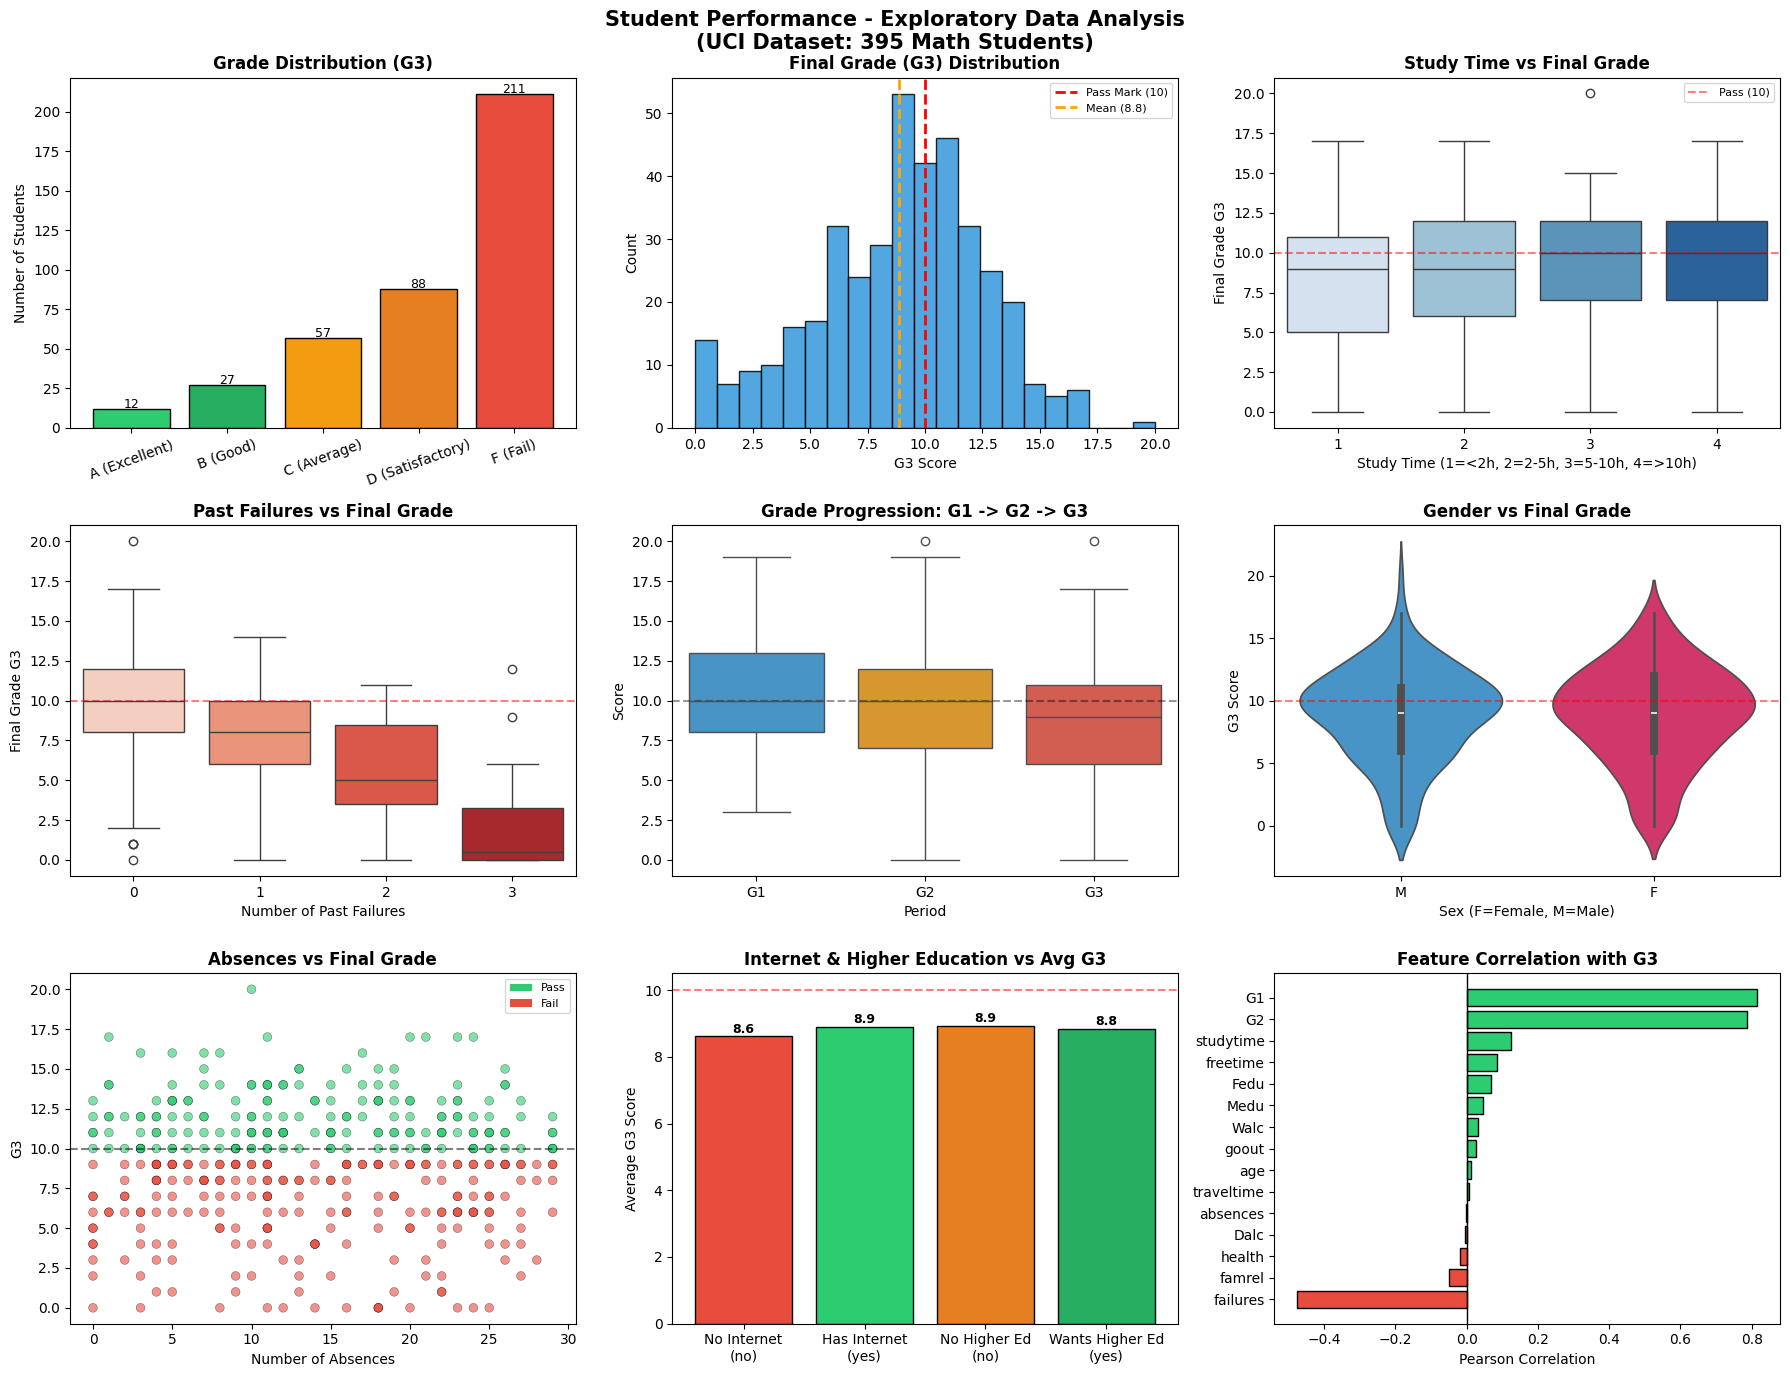

EDA plot -> minor1_eda.png


In [ ]:
print("\n[EDA] Generating visualizations...")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Student Performance - Exploratory Data Analysis\n(UCI Dataset: 395 Math Students)',
             fontsize=15, fontweight='bold')

# 1. Grade Distribution
grade_order = ['A (Excellent)','B (Good)','C (Average)','D (Satisfactory)','F (Fail)']
grade_counts = df['Grade'].value_counts().reindex(grade_order, fill_value=0)
colors_grade = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']
bars = axes[0,0].bar(grade_counts.index, grade_counts.values, color=colors_grade, edgecolor='black')
axes[0,0].set_title('Grade Distribution (G3)', fontweight='bold')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   str(int(bar.get_height())), ha='center', fontsize=9)

# 2. G3 Histogram
axes[0,1].hist(df['G3'], bins=21, range=(0,20), color='#3498db', edgecolor='black', alpha=0.85)
axes[0,1].axvline(10, color='red', linestyle='--', linewidth=2, label='Pass Mark (10)')
axes[0,1].axvline(df['G3'].mean(), color='orange', linestyle='--', linewidth=2,
                  label=f"Mean ({df['G3'].mean():.1f})")
axes[0,1].set_title('Final Grade (G3) Distribution', fontweight='bold')
axes[0,1].set_xlabel('G3 Score'); axes[0,1].set_ylabel('Count')
axes[0,1].legend(fontsize=8)

# 3. Study Time vs G3
sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0,2], palette='Blues')
axes[0,2].set_title('Study Time vs Final Grade', fontweight='bold')
axes[0,2].set_xlabel('Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[0,2].set_ylabel('Final Grade G3')
axes[0,2].axhline(10, color='red', linestyle='--', alpha=0.5, label='Pass (10)')
axes[0,2].legend(fontsize=8)

# 4. Failures vs G3
sns.boxplot(x='failures', y='G3', data=df, ax=axes[1,0], palette='Reds')
axes[1,0].set_title('Past Failures vs Final Grade', fontweight='bold')
axes[1,0].set_xlabel('Number of Past Failures')
axes[1,0].set_ylabel('Final Grade G3')
axes[1,0].axhline(10, color='red', linestyle='--', alpha=0.5)

# 5. G1, G2, G3 Comparison
period_data = df[['G1','G2','G3']].melt(var_name='Period', value_name='Grade_Score')
sns.boxplot(x='Period', y='Grade_Score', data=period_data, ax=axes[1,1],
            palette={'G1':'#3498db','G2':'#f39c12','G3':'#e74c3c'})
axes[1,1].set_title('Grade Progression: G1 -> G2 -> G3', fontweight='bold')
axes[1,1].set_ylabel('Score'); axes[1,1].axhline(10, color='black', linestyle='--', alpha=0.4)

# 6. Sex vs G3
sns.violinplot(x='sex', y='G3', data=df, ax=axes[1,2],
               palette={'F':'#e91e63','M':'#3498db'}, inner='box')
axes[1,2].set_title('Gender vs Final Grade', fontweight='bold')
axes[1,2].set_xlabel('Sex (F=Female, M=Male)')
axes[1,2].set_ylabel('G3 Score')
axes[1,2].axhline(10, color='red', linestyle='--', alpha=0.5)

# 7. Absences vs G3
colors_pass = df['Pass'].map({1:'#2ecc71', 0:'#e74c3c'})
axes[2,0].scatter(df['absences'], df['G3'], c=colors_pass,
                  alpha=0.6, edgecolors='black', linewidths=0.3, s=40)
axes[2,0].axhline(10, color='black', linestyle='--', alpha=0.5, label='Pass (10)')
axes[2,0].set_title('Absences vs Final Grade', fontweight='bold')
axes[2,0].set_xlabel('Number of Absences'); axes[2,0].set_ylabel('G3')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Pass'), Patch(facecolor='#e74c3c', label='Fail')]
axes[2,0].legend(handles=legend_elements, fontsize=8)

# 8. Internet & Higher Edu vs G3
higher_means   = df.groupby('higher')['G3'].mean()
internet_means = df.groupby('internet')['G3'].mean()
categories = ['No Internet\n(no)', 'Has Internet\n(yes)', 'No Higher Ed\n(no)', 'Wants Higher Ed\n(yes)']
values = [internet_means.get('no', 0), internet_means.get('yes', 0),
          higher_means.get('no', 0),   higher_means.get('yes', 0)]
colors_bar2 = ['#e74c3c','#2ecc71','#e67e22','#27ae60']
axes[2,1].bar(categories, values, color=colors_bar2, edgecolor='black')
axes[2,1].set_title('Internet & Higher Education vs Avg G3', fontweight='bold')
axes[2,1].set_ylabel('Average G3 Score')
axes[2,1].axhline(10, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(values):
    axes[2,1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# 9. Correlation with G3
num_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']
corr_g3 = df[num_cols].corr()[['G3']].drop('G3').sort_values('G3')
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_g3['G3']]
axes[2,2].barh(corr_g3.index, corr_g3['G3'], color=colors_corr, edgecolor='black')
axes[2,2].axvline(0, color='black', linewidth=1)
axes[2,2].set_title('Feature Correlation with G3', fontweight='bold')
axes[2,2].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('minor1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot -> minor1_eda.png")

## **Data Preprocessing**

In [ ]:
df_model = df.copy()
le = LabelEncoder()
cat_cols = [c for c in df_model.select_dtypes(include='object').columns if c != 'Grade']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
print(f"  Encoded {len(cat_cols)} categorical columns.")

  Encoded 17 categorical columns.


## **Feature Selection & Splitting**

In [ ]:
FEATURES = ['school','sex','age','address','famsize','Pstatus',
            'Medu','Fedu','traveltime','studytime','failures',
            'schoolsup','famsup','paid','activities','nursery','higher',
            'internet','romantic','famrel','freetime','goout',
            'Dalc','Walc','health','absences','G1','G2']
TARGET = 'Pass'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"\n  Features : {len(FEATURES)}")
print(f"  Target   : {TARGET}  (1=Pass, 0=Fail)")
print(f"  Pass={y.sum()}  Fail={len(y)-y.sum()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"  Train: {len(X_train)} | Test: {len(X_test)}")


  Features : 28
  Target   : Pass  (1=Pass, 0=Fail)
  Pass=184  Fail=211
  Train: 316 | Test: 79


## **Train & Evaluate Models**

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42)
}

results   = {}
cv_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name]   = acc
    cv_scores[name] = cv
    print(f"\n{name}:")
    print(f"  Test Acc: {acc*100:.2f}%  |  CV Acc: {cv.mean()*100:.2f}% +/- {cv.std()*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))

best_name  = max(results, key=results.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)
print(f"\n  Best Model: {best_name}  ({results[best_name]*100:.2f}%)")


Logistic Regression:
  Test Acc: 82.28%  |  CV Acc: 80.76% +/- 4.49%
              precision    recall  f1-score   support

        Fail       0.91      0.74      0.82        42
        Pass       0.76      0.92      0.83        37

    accuracy                           0.82        79
   macro avg       0.83      0.83      0.82        79
weighted avg       0.84      0.82      0.82        79


Decision Tree:
  Test Acc: 72.15%  |  CV Acc: 76.96% +/- 4.03%
              precision    recall  f1-score   support

        Fail       0.75      0.71      0.73        42
        Pass       0.69      0.73      0.71        37

    accuracy                           0.72        79
   macro avg       0.72      0.72      0.72        79
weighted avg       0.72      0.72      0.72        79


Random Forest:
  Test Acc: 84.81%  |  CV Acc: 80.25% +/- 4.78%
              precision    recall  f1-score   support

        Fail       0.92      0.79      0.85        42
        Pass       0.79      0.92      

## **Visualize Results**

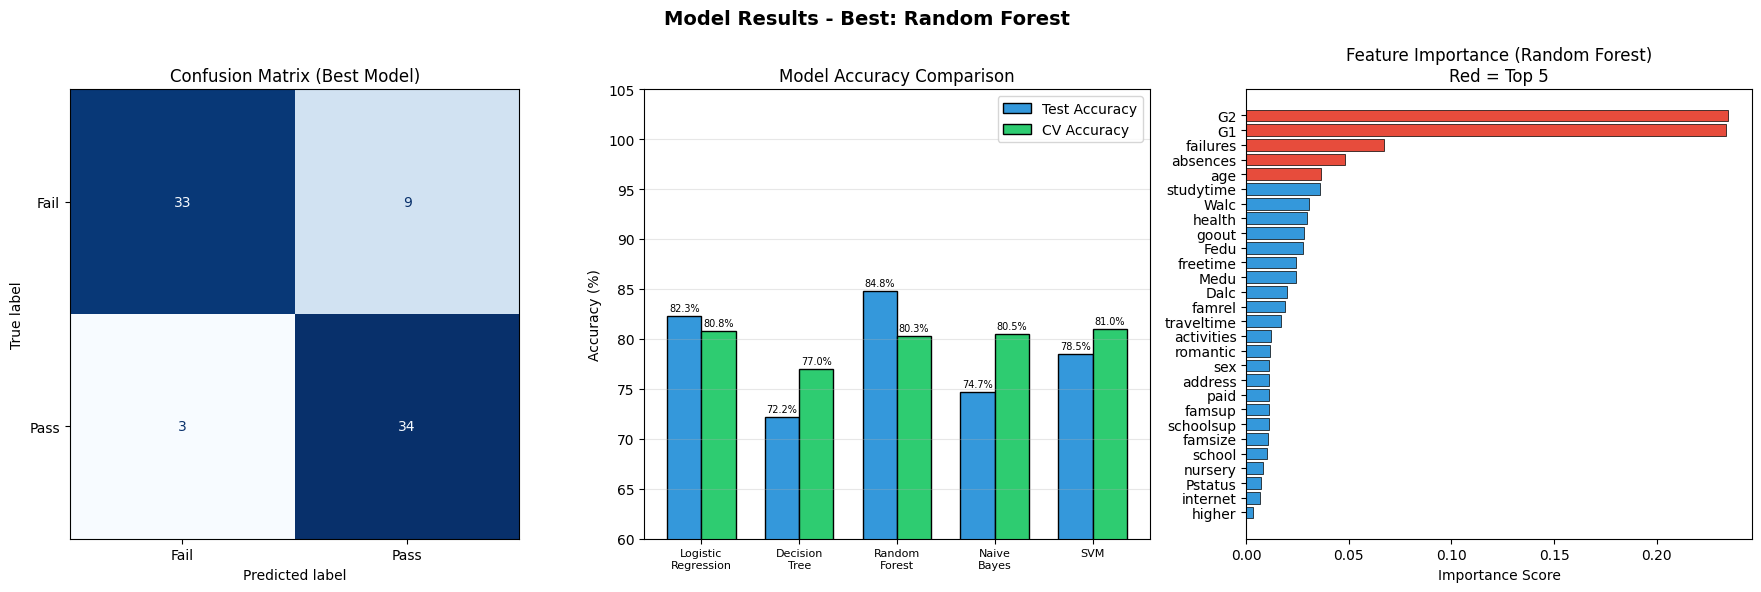

Model results -> minor1_model_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Model Results - Best: {best_name}', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Best Model)')

# Accuracy comparison
names = list(results.keys())
accs  = [results[n]*100 for n in names]
cv_m  = [cv_scores[n].mean()*100 for n in names]
x = np.arange(len(names)); w = 0.35
axes[1].bar(x - w/2, accs, w, label='Test Accuracy', color='#3498db', edgecolor='black')
axes[1].bar(x + w/2, cv_m, w, label='CV Accuracy',   color='#2ecc71', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ','\n') for n in names], fontsize=8)
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(60, 105)
axes[1].set_title('Model Accuracy Comparison'); axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (a, c) in enumerate(zip(accs, cv_m)):
    axes[1].text(i - w/2, a + 0.5, f'{a:.1f}%', ha='center', fontsize=7)
    axes[1].text(i + w/2, c + 0.5, f'{c:.1f}%', ha='center', fontsize=7)

# Feature Importance
rf  = models['Random Forest']
fi  = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': fi})
fi_df.sort_values('Importance', ascending=True, inplace=True)
colors_fi = ['#e74c3c' if i >= len(fi_df)-5 else '#3498db' for i in range(len(fi_df))]
axes[2].barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi, edgecolor='black', linewidth=0.5)
axes[2].set_title('Feature Importance (Random Forest)\nRed = Top 5')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('minor1_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model results -> minor1_model_results.png")

## **Predict on Sample Students**

In [ ]:
sample_idx = [0, 50, 100, 200, 350]
sample_df  = df_model.iloc[sample_idx]
X_sample   = scaler.transform(sample_df[FEATURES])
y_preds    = best_model.predict(X_sample)
y_actual   = sample_df[TARGET].values
g3_actual  = df.iloc[sample_idx]['G3'].values

print(f"\n{'Row':>4} | {'G1':>4} {'G2':>4} {'G3':>4} | {'Actual':>8} | {'Predicted':>10} | {'Match':>5}")
print("-" * 55)
for i, idx in enumerate(sample_idx):
    g1   = df.iloc[idx]['G1']
    g2   = df.iloc[idx]['G2']
    g3   = g3_actual[i]
    act  = 'Pass' if y_actual[i] == 1 else 'Fail'
    pred = 'Pass' if y_preds[i]  == 1 else 'Fail'
    chk  = 'YES' if act == pred else 'NO'
    print(f"  {idx:3d} | {g1:4.0f} {g2:4.0f} {g3:4.0f} | {act:>8} | {pred:>10} | {chk:>5}")


 Row |   G1   G2   G3 |   Actual |  Predicted | Match
-------------------------------------------------------
    0 |    7    6    5 |     Fail |       Fail |   YES
   50 |    9    9    8 |     Fail |       Fail |   YES
  100 |   13   14    8 |     Fail |       Fail |   YES
  200 |   10    9   10 |     Pass |       Pass |   YES
  350 |   13   12   14 |     Pass |       Pass |   YES


## **Final Summary Plot**

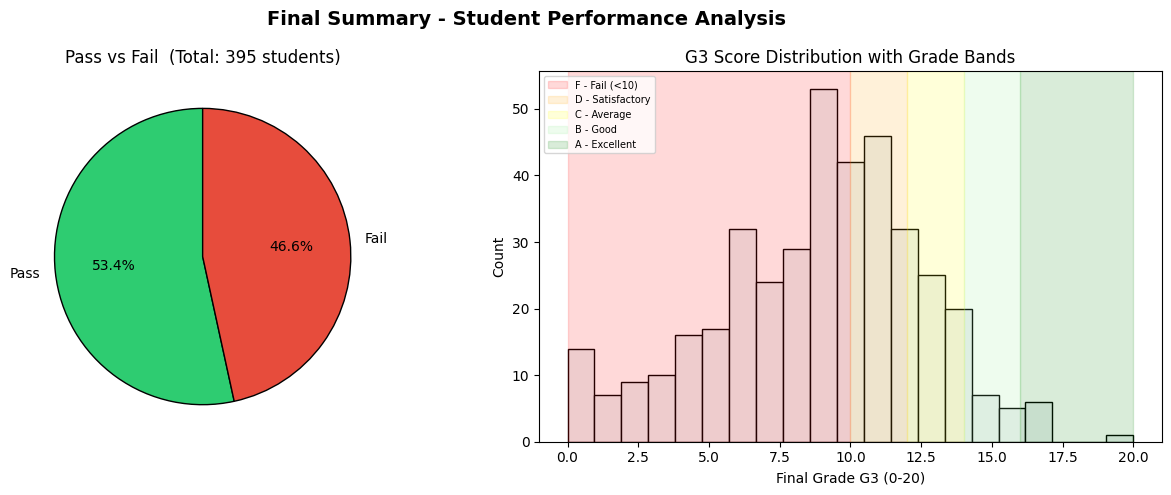

Summary -> minor1_summary.png

PROJECT SUMMARY
  Dataset       : UCI Student Performance (student-mat.csv)
  Total Students: 395
  Features Used : 28
  Best Model    : Random Forest
  Best Accuracy : 84.81%
  Pass Rate     : 46.6%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Final Summary - Student Performance Analysis', fontsize=14, fontweight='bold')

pass_counts = df['Pass'].value_counts()
axes[0].pie(pass_counts, labels=['Pass','Fail'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'black'})
axes[0].set_title(f'Pass vs Fail  (Total: {len(df)} students)')

axes[1].hist(df['G3'], bins=21, range=(0,20), color='#ecf0f1', edgecolor='black')
axes[1].axvspan(0,  10, alpha=0.15, color='red',        label='F - Fail (<10)')
axes[1].axvspan(10, 12, alpha=0.15, color='orange',     label='D - Satisfactory')
axes[1].axvspan(12, 14, alpha=0.15, color='yellow',     label='C - Average')
axes[1].axvspan(14, 16, alpha=0.15, color='lightgreen', label='B - Good')
axes[1].axvspan(16, 20, alpha=0.15, color='green',      label='A - Excellent')
axes[1].set_title('G3 Score Distribution with Grade Bands')
axes[1].set_xlabel('Final Grade G3 (0-20)'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('minor1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary -> minor1_summary.png")

print("\n" + "=" * 65)
print("PROJECT SUMMARY")
print("=" * 65)
print(f"  Dataset       : UCI Student Performance (student-mat.csv)")
print(f"  Total Students: {len(df)}")
print(f"  Features Used : {len(FEATURES)}")
print(f"  Best Model    : {best_name}")
print(f"  Best Accuracy : {results[best_name]*100:.2f}%")
print(f"  Pass Rate     : {df['Pass'].mean()*100:.1f}%")